# Log preprocessing inspection

This notebook does four things:

1. Loads the manual RGB-D log (`rgb.npy`, `depth.npy`, `metadata.json`).
2. Generates the visual memory using `VisualMemorySelector`.
3. Builds the processed log for navigator training.
4. Visualizes processed samples for inspection using:
   - frame index
   - original user command
   - processed command
   - observed RGB image
   - theoretical key RGB image

Depth is ignored in the visualization, as requested.

In [1]:
import os
import json
from typing import List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from visual_memory_selector import VisualMemorySelector

In [2]:
# ------------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------------

rgb_npy_path = "/home/rodriguez/Documents/GitHub/habitat/habitat-lab/manual_operation/simple_logs/rep_rep_dinning-0_224_20260328_084403_rgb.npy"
depth_npy_path = "/home/rodriguez/Documents/GitHub/habitat/habitat-lab/manual_operation/simple_logs/rep_rep_dinning-0_224_20260328_084403_depth.npy"
metadata_json_path = "/home/rodriguez/Documents/GitHub/habitat/habitat-lab/manual_operation/simple_logs/rep_rep_dinning-0_224_20260328_084403_metadata.json"

# Visual memory selection hyperparameters
sigma_k = 2.0
sample_rate = 1

# Optional output directory if you want to save selector outputs
save_selector_outputs = False
selector_output_dir = "/home/rodriguez/Documents/GitHub/habitat/habitat-lab/manual_operation/simple_logs/visual_memory_debug"

# Visualization defaults
default_inspect_index = 0

In [3]:
# ------------------------------------------------------------------
# LOAD RAW LOG DATA
# ------------------------------------------------------------------

if not os.path.exists(rgb_npy_path):
    raise FileNotFoundError(rgb_npy_path)
if not os.path.exists(depth_npy_path):
    raise FileNotFoundError(depth_npy_path)
if not os.path.exists(metadata_json_path):
    raise FileNotFoundError(metadata_json_path)

rgb_frames = np.load(rgb_npy_path)
depth_frames = np.load(depth_npy_path)

with open(metadata_json_path, "r", encoding="utf-8") as f:
    metadata = json.load(f)

steps = metadata["steps"]

print("RGB frames shape:", rgb_frames.shape)
print("Depth frames shape:", depth_frames.shape)
print("Metadata keys:", list(metadata.keys()))
print("Number of logged steps:", len(steps))

assert len(rgb_frames) == len(steps), "Mismatch between rgb frames and metadata steps."

RGB frames shape: (266, 256, 256, 3)
Depth frames shape: (266, 256, 256, 1)
Metadata keys: ['run_name', 'environment_name', 'scene_path', 'path_name', 'id_run', 'forward_step_size', 'turn_angle', 'start_pose', 'num_logged_frames', 'steps']
Number of logged steps: 266


In [4]:
# ------------------------------------------------------------------
# GENERATE VISUAL MEMORY
# ------------------------------------------------------------------

selector = VisualMemorySelector(sigma_k=sigma_k)
selection_result = selector.select_from_arrays(
    rgb_frames=rgb_frames,
    depth_frames=depth_frames,
    sample_rate=sample_rate,
)

selected_indices = selection_result["selected_real_indices"]
threshold = selection_result["threshold"]
mu = selection_result["mu"]
sigma = selection_result["sigma"]

print(f"Threshold: {threshold:.4f}")
print(f"Mean(D1): {mu:.4f}")
print(f"Std(D1): {sigma:.4f}")
print("Selected keyframe indices:")
print(selected_indices)

if save_selector_outputs:
    selector.save_outputs(
        output_dir=selector_output_dir,
        rgb_frames=rgb_frames,
        depth_frames=depth_frames,
        result=selection_result,
        save_matrix_csv=True,
    )
    print(f"Selector outputs saved to: {selector_output_dir}")

/home/rodriguez/miniconda3/envs/habitat/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/rodriguez/miniconda3/envs/habitat/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/rodriguez/Documents/GitHub/habitat/habitat-lab/examples/modules/rgbd_similarity.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary cod

Threshold: 0.9280
Mean(D1): 0.9517
Std(D1): 0.0118
Selected keyframe indices:
[0, 3, 5, 8, 12, 17, 21, 24, 28, 30, 32, 35, 38, 40, 43, 45, 47, 49, 51, 53, 55, 58, 61, 62, 66, 69, 72, 74, 77, 80, 82, 86, 91, 97, 99, 103, 106, 109, 113, 116, 118, 120, 123, 124, 127, 130, 134, 136, 139, 141, 143, 145, 147, 149, 151, 153, 157, 160, 163, 165, 169, 172, 175, 178, 181, 183, 187, 189, 191, 193, 195, 197, 199, 201, 204, 207, 209, 211, 214, 217, 219, 222, 225, 228, 230, 232, 234, 236, 238, 240, 243, 246, 247, 248, 250, 254, 256, 258, 259, 262, 265]


In [5]:
# ------------------------------------------------------------------
# QUICK SUMMARY TABLE FOR SELECTED KEYFRAMES
# ------------------------------------------------------------------

selected_df = pd.DataFrame({
    "keyframe_order": list(range(len(selected_indices))),
    "frame_idx": selected_indices,
})

display(selected_df)

,keyframe_order,frame_idx
0,0,0
1,1,3
2,2,5
3,3,8
4,4,12
...,...,...
96,96,256
97,97,258
98,98,259
99,99,262


In [6]:
# ------------------------------------------------------------------
# PREPROCESSING LOGIC
# ------------------------------------------------------------------

def build_segment_lookup(selected_indices: List[int], num_frames: int) -> List[int]:
    """
    For every raw frame index i, return the active target keyframe after the most recent
    update-memory event.
    
    Example with selected_indices = [0, 4, 14]:
      frame 0 -> active target after duplication becomes 4
      frames 1..3 -> target 4
      frame 4 -> active target after duplication becomes 14
      frames 5..13 -> target 14
    
    For the last selected frame, there is no next keyframe. Those rows can still produce
    an 'update_memory' sample, but not a duplicated next-target motion sample.
    """
    selected_sorted = sorted(selected_indices)
    target_lookup = [None] * num_frames

    for k in range(len(selected_sorted) - 1):
        start_kf = selected_sorted[k]
        next_kf = selected_sorted[k + 1]

        # From the selected frame itself onward until the frame before next_kf,
        # the active motion target is next_kf.
        for i in range(start_kf, next_kf):
            target_lookup[i] = next_kf

    # Last keyframe has no subsequent motion target.
    last_kf = selected_sorted[-1]
    target_lookup[last_kf] = None

    return target_lookup


def preprocess_log_for_training(metadata_steps: List[Dict], selected_indices: List[int]) -> pd.DataFrame:
    """
    Build the processed log using the agreed semi-automatic logic.

    Rules:
    - Every raw frame becomes at least one processed sample.
    - If raw frame i is NOT a selected keyframe:
        keep original command and assign the active target keyframe.
    - If raw frame i IS a selected keyframe:
        add one sample with processed_command='update_memory' and target_keyframe=i.
        if a next keyframe exists and original command is not finish:
            add a duplicated sample with processed_command=original_command and
            target_keyframe=next_selected_keyframe.
    """
    num_frames = len(metadata_steps)
    selected_set = set(selected_indices)
    selected_sorted = sorted(selected_indices)
    active_target_lookup = build_segment_lookup(selected_sorted, num_frames)

    next_keyframe_map = {}
    for k in range(len(selected_sorted) - 1):
        next_keyframe_map[selected_sorted[k]] = selected_sorted[k + 1]
    next_keyframe_map[selected_sorted[-1]] = None

    processed_rows = []

    for step in metadata_steps:
        frame_id = int(step["frame_id"])
        user_command = step["user_command"]

        if frame_id in selected_set:
            # Sample 1: reached selected keyframe -> update memory
            processed_rows.append({
                "raw_frame_id": frame_id,
                "user_command": user_command,
                "processed_command": "update_memory",
                "target_keyframe": frame_id,
                "row_type": "selected_frame_update",
                "position": step.get("position", None),
                "rotation_quaternion_wxyz": step.get("rotation_quaternion_wxyz", None),
            })

            # Sample 2: same observation, but now target becomes next keyframe
            next_kf = next_keyframe_map[frame_id]
            if next_kf is not None and user_command != "finish":
                processed_rows.append({
                    "raw_frame_id": frame_id,
                    "user_command": user_command,
                    "processed_command": user_command,
                    "target_keyframe": next_kf,
                    "row_type": "selected_frame_duplicate_next_target",
                    "position": step.get("position", None),
                    "rotation_quaternion_wxyz": step.get("rotation_quaternion_wxyz", None),
                })
        else:
            target_kf = active_target_lookup[frame_id]
            processed_rows.append({
                "raw_frame_id": frame_id,
                "user_command": user_command,
                "processed_command": user_command,
                "target_keyframe": target_kf,
                "row_type": "regular_motion",
                "position": step.get("position", None),
                "rotation_quaternion_wxyz": step.get("rotation_quaternion_wxyz", None),
            })

    df = pd.DataFrame(processed_rows)
    return df

In [7]:
# ------------------------------------------------------------------
# RUN PREPROCESSING
# ------------------------------------------------------------------

processed_df = preprocess_log_for_training(steps, selected_indices)

print("Processed log shape:", processed_df.shape)
display(processed_df.head(20))

Processed log shape: (366, 7)


,raw_frame_id,user_command,processed_command,target_keyframe,row_type,position,rotation_quaternion_wxyz
0,0,forward,update_memory,0,selected_frame_update,"[0.6751305460929871, 0.07244700193405151, -3.2...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
1,0,forward,forward,3,selected_frame_duplicate_next_target,"[0.6751305460929871, 0.07244700193405151, -3.2...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
2,1,forward,forward,3,regular_motion,"[0.6560497879981995, 0.07244700193405151, -3.1...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
3,2,forward,forward,3,regular_motion,"[0.6369690299034119, 0.07244700193405151, -3.0...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
4,3,forward,update_memory,3,selected_frame_update,"[0.6178882718086243, 0.07244700193405151, -2.9...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
5,3,forward,forward,5,selected_frame_duplicate_next_target,"[0.6178882718086243, 0.07244700193405151, -2.9...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
6,4,forward,forward,5,regular_motion,"[0.5988075137138367, 0.07244700193405151, -2.8...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
7,5,forward,update_memory,5,selected_frame_update,"[0.5797267556190491, 0.07244700193405151, -2.7...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
8,5,forward,forward,8,selected_frame_duplicate_next_target,"[0.5797267556190491, 0.07244700193405151, -2.7...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
9,6,forward,forward,8,regular_motion,"[0.5606459975242615, 0.07244700193405151, -2.6...","[0.09584498405456543, 0.0, 0.9953963160514832,..."


In [8]:
# ------------------------------------------------------------------
# CLASS COUNTS AFTER PROCESSING
# ------------------------------------------------------------------

display(processed_df["processed_command"].value_counts(dropna=False).to_frame("count"))

,count
processed_command,
forward,133
update_memory,101
left,90
right,42


In [9]:
# ------------------------------------------------------------------
# VISUAL INSPECTION UTILITIES
# ------------------------------------------------------------------

def inspect_processed_sample(idx: int, processed_df: pd.DataFrame, rgb_frames: np.ndarray):
    if idx < 0 or idx >= len(processed_df):
        raise IndexError(f"idx must be in [0, {len(processed_df)-1}]")

    row = processed_df.iloc[idx]

    raw_frame_id = int(row["raw_frame_id"])
    target_keyframe = row["target_keyframe"]
    user_command = row["user_command"]
    processed_command = row["processed_command"]
    row_type = row["row_type"]

    observed_rgb = rgb_frames[raw_frame_id]

    if target_keyframe is None or (isinstance(target_keyframe, float) and np.isnan(target_keyframe)):
        key_rgb = np.zeros_like(observed_rgb)
        target_title = "None"
    else:
        target_keyframe = int(target_keyframe)
        key_rgb = rgb_frames[target_keyframe]
        target_title = str(target_keyframe)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(observed_rgb)
    axes[0].set_title(f"Observed RGB | raw frame {raw_frame_id}")
    axes[0].axis("off")

    axes[1].imshow(key_rgb)
    axes[1].set_title(f"Theoretical key RGB | target {target_title}")
    axes[1].axis("off")

    plt.suptitle(
        f"idx={idx} | user={user_command} | processed={processed_command} | row_type={row_type}",
        fontsize=12
    )
    plt.tight_layout()
    plt.show()

    display(pd.DataFrame([row]))


def inspect_raw_frame_group(raw_frame_id: int, processed_df: pd.DataFrame, rgb_frames: np.ndarray):
    subset = processed_df[processed_df["raw_frame_id"] == raw_frame_id].reset_index(drop=True)
    if len(subset) == 0:
        print(f"No processed rows for raw_frame_id={raw_frame_id}")
        return

    print(f"Found {len(subset)} processed rows for raw_frame_id={raw_frame_id}")
    display(subset)

    for i in range(len(subset)):
        row = subset.iloc[i]
        temp_df = subset.iloc[[i]].reset_index(drop=True)
        inspect_processed_sample_global_row(row.name if hasattr(row, 'name') else 0)


def inspect_processed_sample_global_row(global_idx: int):
    inspect_processed_sample(global_idx, processed_df, rgb_frames)

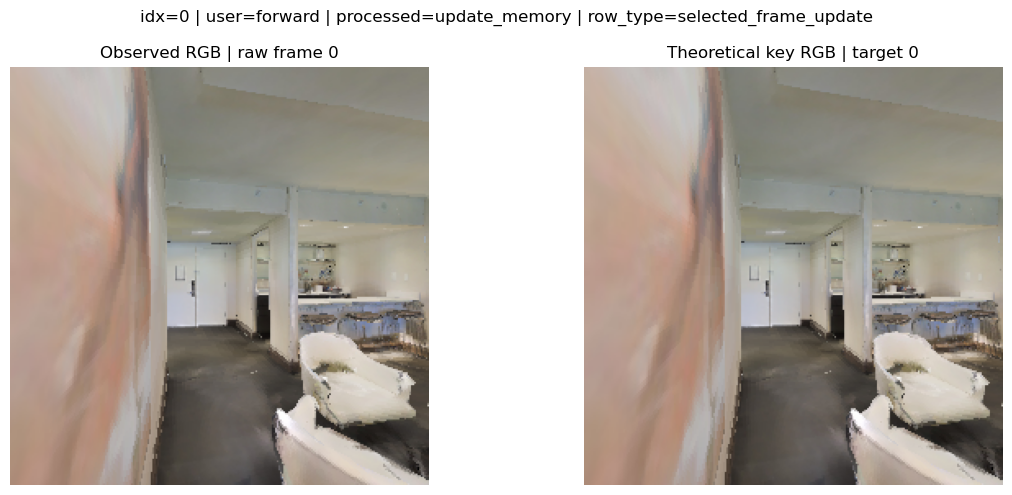

,raw_frame_id,user_command,processed_command,target_keyframe,row_type,position,rotation_quaternion_wxyz
0,0,forward,update_memory,0,selected_frame_update,"[0.6751305460929871, 0.07244700193405151, -3.2...","[0.09584498405456543, 0.0, 0.9953963160514832,..."


In [10]:
# ------------------------------------------------------------------
# DEFAULT INSPECTION
# ------------------------------------------------------------------

inspect_processed_sample(default_inspect_index, processed_df, rgb_frames)

In [11]:
# ------------------------------------------------------------------
# HELPFUL LOOKUPS FOR INSPECTION
# ------------------------------------------------------------------

selected_update_rows = processed_df[processed_df["row_type"] == "selected_frame_update"]
selected_duplicate_rows = processed_df[processed_df["row_type"] == "selected_frame_duplicate_next_target"]

print("Selected-frame update rows:")
display(selected_update_rows.head(20))

print("Selected-frame duplicate-next-target rows:")
display(selected_duplicate_rows.head(20))

Selected-frame update rows:


,raw_frame_id,user_command,processed_command,target_keyframe,row_type,position,rotation_quaternion_wxyz
0,0,forward,update_memory,0,selected_frame_update,"[0.6751305460929871, 0.07244700193405151, -3.2...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
4,3,forward,update_memory,3,selected_frame_update,"[0.6178882718086243, 0.07244700193405151, -2.9...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
7,5,forward,update_memory,5,selected_frame_update,"[0.5797267556190491, 0.07244700193405151, -2.7...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
11,8,forward,update_memory,8,selected_frame_update,"[0.5224844813346863, 0.07244700193405151, -2.4...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
16,12,forward,update_memory,12,selected_frame_update,"[0.48090875148773193, 0.07244700193405151, -2....","[0.13052543997764587, 0.0, 0.991445004940033, ..."
22,17,right,update_memory,17,selected_frame_update,"[0.3932332694530487, 0.07244700193405151, -1.9...","[0.16504685580730438, 0.0, 0.9862858057022095,..."
27,21,right,update_memory,21,selected_frame_update,"[0.31832367181777954, 0.07244700193405151, -1....","[0.19936718046665192, 0.0, 0.9799248576164246,..."
31,24,forward,update_memory,24,selected_frame_update,"[0.2760619819164276, 0.07244700193405151, -1.7...","[0.23344461619853973, 0.0, 0.9723701477050781,..."
36,28,right,update_memory,28,selected_frame_update,"[0.23066306114196777, 0.07244700193405151, -1....","[0.28401461243629456, 0.0, 0.9588199853897095,..."
39,30,right,update_memory,30,selected_frame_update,"[0.23066306114196777, 0.07244700193405151, -1....","[0.31730392575263977, 0.0, 0.9483239650726318,..."


Selected-frame duplicate-next-target rows:


,raw_frame_id,user_command,processed_command,target_keyframe,row_type,position,rotation_quaternion_wxyz
1,0,forward,forward,3,selected_frame_duplicate_next_target,"[0.6751305460929871, 0.07244700193405151, -3.2...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
5,3,forward,forward,5,selected_frame_duplicate_next_target,"[0.6178882718086243, 0.07244700193405151, -2.9...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
8,5,forward,forward,8,selected_frame_duplicate_next_target,"[0.5797267556190491, 0.07244700193405151, -2.7...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
12,8,forward,forward,12,selected_frame_duplicate_next_target,"[0.5224844813346863, 0.07244700193405151, -2.4...","[0.09584498405456543, 0.0, 0.9953963160514832,..."
17,12,forward,forward,17,selected_frame_duplicate_next_target,"[0.48090875148773193, 0.07244700193405151, -2....","[0.13052543997764587, 0.0, 0.991445004940033, ..."
23,17,right,right,21,selected_frame_duplicate_next_target,"[0.3932332694530487, 0.07244700193405151, -1.9...","[0.16504685580730438, 0.0, 0.9862858057022095,..."
28,21,right,right,24,selected_frame_duplicate_next_target,"[0.31832367181777954, 0.07244700193405151, -1....","[0.19936718046665192, 0.0, 0.9799248576164246,..."
32,24,forward,forward,28,selected_frame_duplicate_next_target,"[0.2760619819164276, 0.07244700193405151, -1.7...","[0.23344461619853973, 0.0, 0.9723701477050781,..."
37,28,right,right,30,selected_frame_duplicate_next_target,"[0.23066306114196777, 0.07244700193405151, -1....","[0.28401461243629456, 0.0, 0.9588199853897095,..."
40,30,right,right,32,selected_frame_duplicate_next_target,"[0.23066306114196777, 0.07244700193405151, -1....","[0.31730392575263977, 0.0, 0.9483239650726318,..."


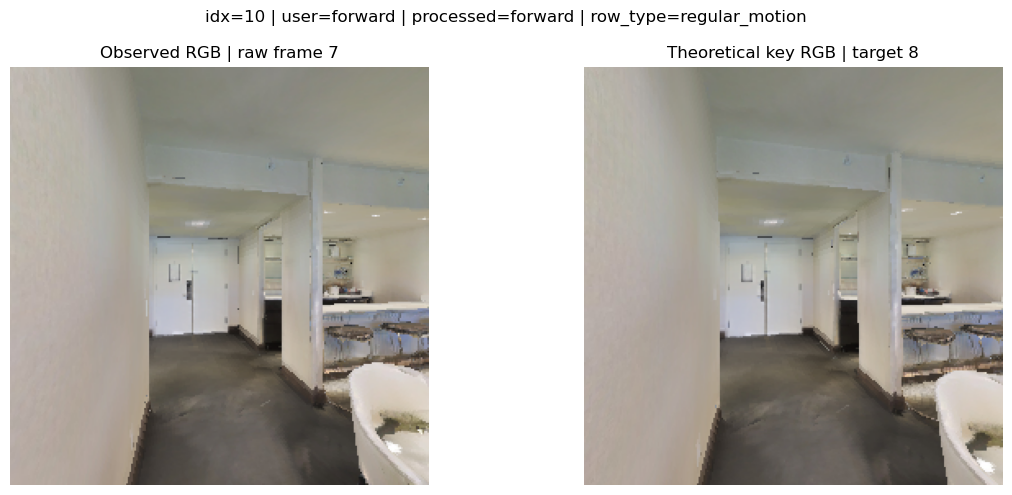

,raw_frame_id,user_command,processed_command,target_keyframe,row_type,position,rotation_quaternion_wxyz
10,7,forward,forward,8,regular_motion,"[0.5415652394294739, 0.07244700193405151, -2.5...","[0.09584498405456543, 0.0, 0.9953963160514832,..."


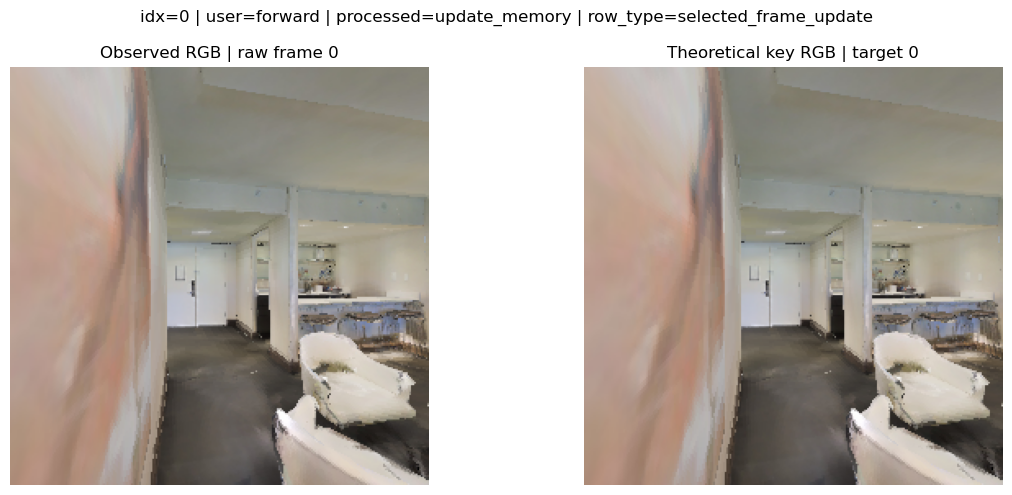

,raw_frame_id,user_command,processed_command,target_keyframe,row_type,position,rotation_quaternion_wxyz
0,0,forward,update_memory,0,selected_frame_update,"[0.6751305460929871, 0.07244700193405151, -3.2...","[0.09584498405456543, 0.0, 0.9953963160514832,..."


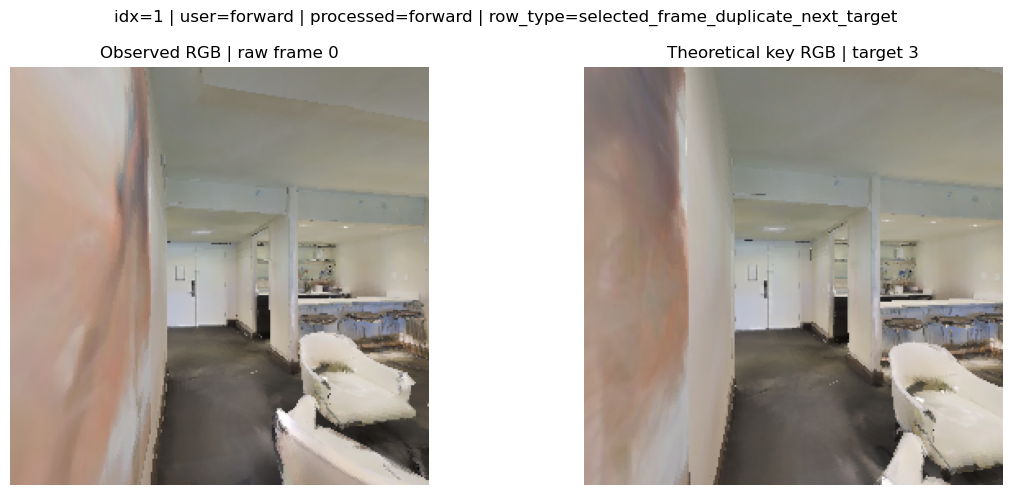

,raw_frame_id,user_command,processed_command,target_keyframe,row_type,position,rotation_quaternion_wxyz
1,0,forward,forward,3,selected_frame_duplicate_next_target,"[0.6751305460929871, 0.07244700193405151, -3.2...","[0.09584498405456543, 0.0, 0.9953963160514832,..."


In [12]:
# ------------------------------------------------------------------
# MANUAL INSPECTION EXAMPLES
# Edit these indices as needed.
# ------------------------------------------------------------------

# Example 1: inspect an arbitrary processed row
inspect_processed_sample(10, processed_df, rgb_frames)

# Example 2: inspect first update-memory row
first_update_idx = selected_update_rows.index[0]
inspect_processed_sample(first_update_idx, processed_df, rgb_frames)

# Example 3: inspect first duplicated selected-frame row, if it exists
if len(selected_duplicate_rows) > 0:
    first_dup_idx = selected_duplicate_rows.index[0]
    inspect_processed_sample(first_dup_idx, processed_df, rgb_frames)

In [13]:
# ------------------------------------------------------------------
# OPTIONAL: SAVE PROCESSED LOG
# ------------------------------------------------------------------

save_processed = False
processed_csv_path = "manual_operation/simple_logs/processed_log_debug.csv"

if save_processed:
    processed_df.to_csv(processed_csv_path, index=False)
    print(f"Processed log saved to: {processed_csv_path}")